# 🛍️ Mall Customer Segmentation using K-Means Clustering

## Objective
To group customers of a retail store based on purchase behavior using K-Means clustering and identify distinct customer segments for business insights.

## Dataset
Mall Customers Dataset containing:
- CustomerID
- Gender
- Age
- Annual Income (k$)
- Spending Score (1-100)

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Step 1: Load Dataset

The dataset is imported into the notebook for preprocessing and analysis.

In [3]:
df = pd.read_csv('/content/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Step 2: Explore Dataset

Check dataset size, columns, and data types.

In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
df.info()

Shape: (200, 5)

Columns:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


## Step 3: Check Missing Values

Verify whether the dataset contains null values.

In [6]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


## Step 4: Select Features for Clustering

For customer segmentation, use:
- Annual Income (k$)
- Spending Score (1-100)

These two features clearly represent purchasing behavior.

In [7]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## Step 5: Feature Scaling

Scale the selected features so both contribute equally to distance calculations.

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

## Step 6: Elbow Method

Use WCSS to determine the optimal number of clusters.

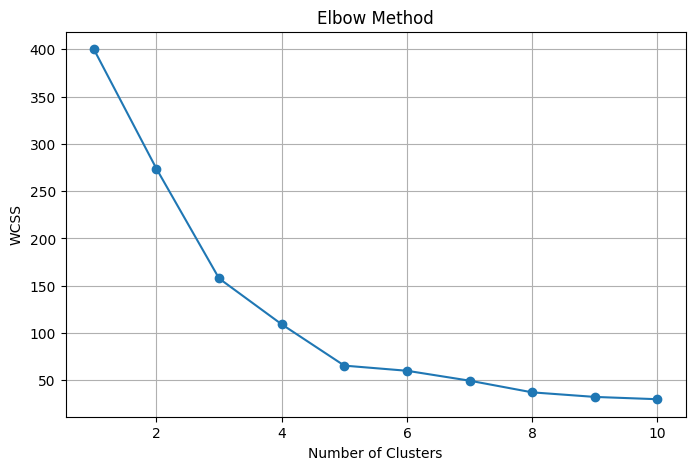

In [9]:
wcss = []

for i in range(1, 11):
    model = KMeans(n_clusters=i, init='k-means++', random_state=42)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

## Step 7: Train K-Means Model

Based on the elbow graph, choose 5 clusters and train the model.

In [10]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## Step 8: Visualize Clusters

Plot customer groups based on annual income and spending score.

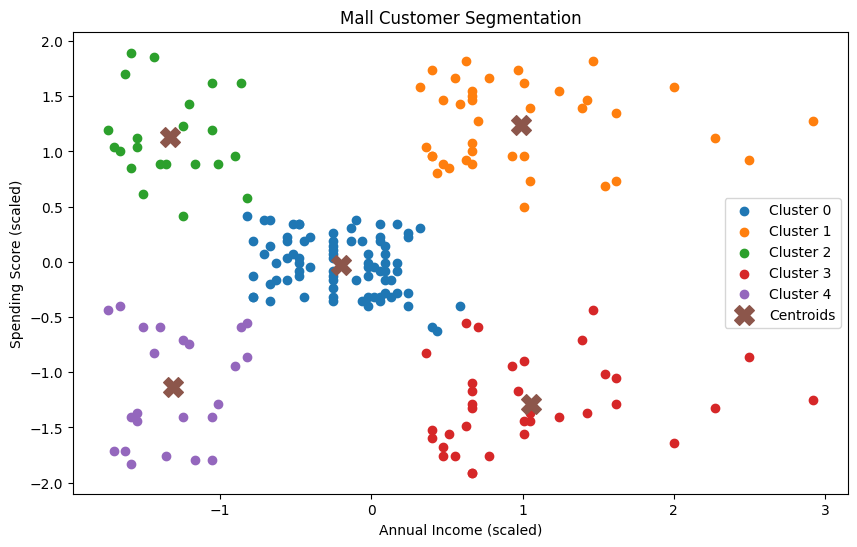

In [11]:
plt.figure(figsize=(10,6))

for i in range(5):
    plt.scatter(
        X_scaled[clusters == i, 0],
        X_scaled[clusters == i, 1],
        label=f'Cluster {i}'
    )

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=200,
    marker='X',
    label='Centroids'
)

plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.title('Mall Customer Segmentation')
plt.legend()
plt.show()

## Step 9: Cluster Summary

Count the number of customers in each cluster.

In [12]:
df['Cluster'].value_counts()

,count
Cluster,
0,81
1,39
3,35
4,23
2,22


## Step 10: Save Output

Save the final clustered dataset.

In [13]:
df.to_csv('clustered_customers_output.csv', index=False)
print("Clustered output saved successfully.")

Clustered output saved successfully.


In [14]:
df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


## Conclusion

The K-Means clustering algorithm successfully segmented mall customers into 5 groups based on annual income and spending score.

These clusters can help businesses:
- Identify high-value customers
- Understand spending behavior
- Improve targeted marketing
- Personalize offers